# E-commerce order Dataset
## Project 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [ ]:
data = pd.read_csv("/content/Dataset for Data Analytics.csv")
print(data.shape)
data.info()

(1200, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [ ]:
print("Null values count:",data.isnull().sum(),sep="\n")

Null values count:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [ ]:
data.drop_duplicates()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


# Missing Values Handling

In [ ]:
data['CouponCode']=data['CouponCode'].fillna('N/A')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


# Outlier Treatment using IQR

In [ ]:
num_cols=['Quantity','UnitPrice','ItemsInCart','TotalPrice']

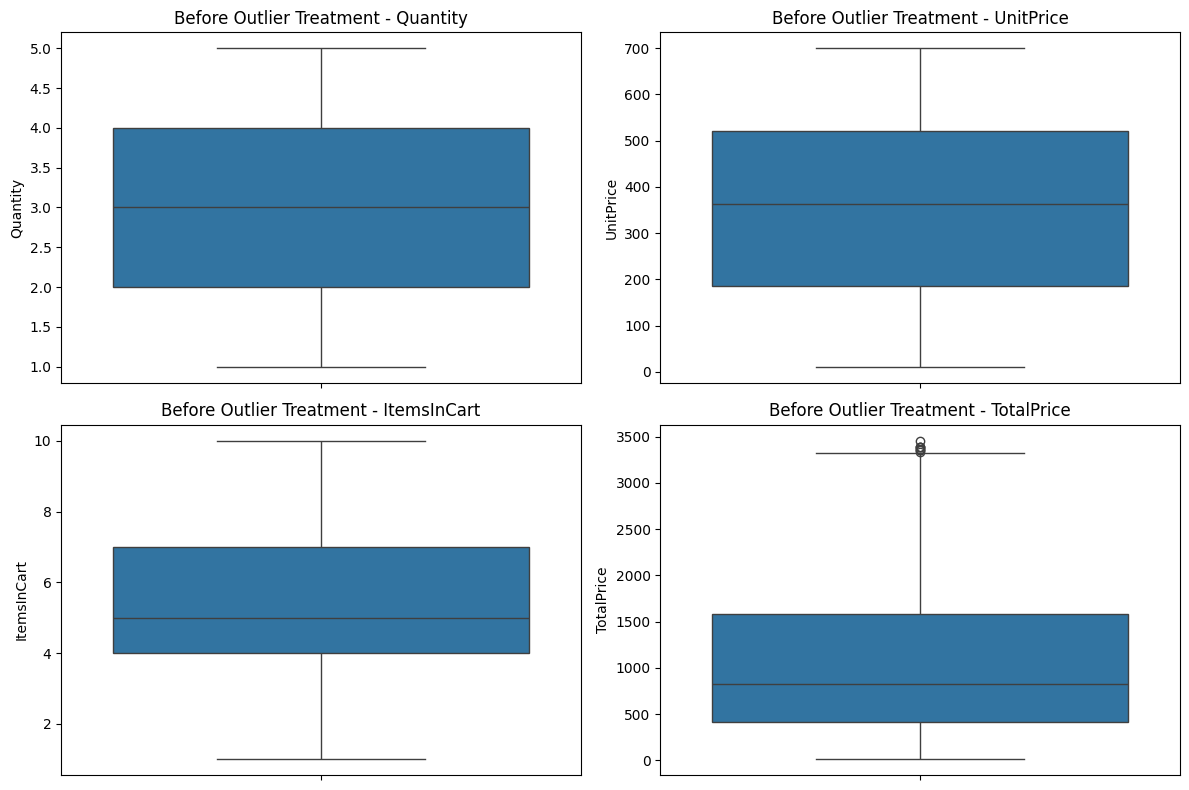

In [ ]:
plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=data[col])
    plt.title(f'Before Outlier Treatment - {col}')

plt.tight_layout()
plt.show()

In [ ]:
for col in num_cols:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  data[col] = np.where(data[col] < lower, lower, data[col])
  data[col] = np.where(data[col] > upper, upper, data[col])

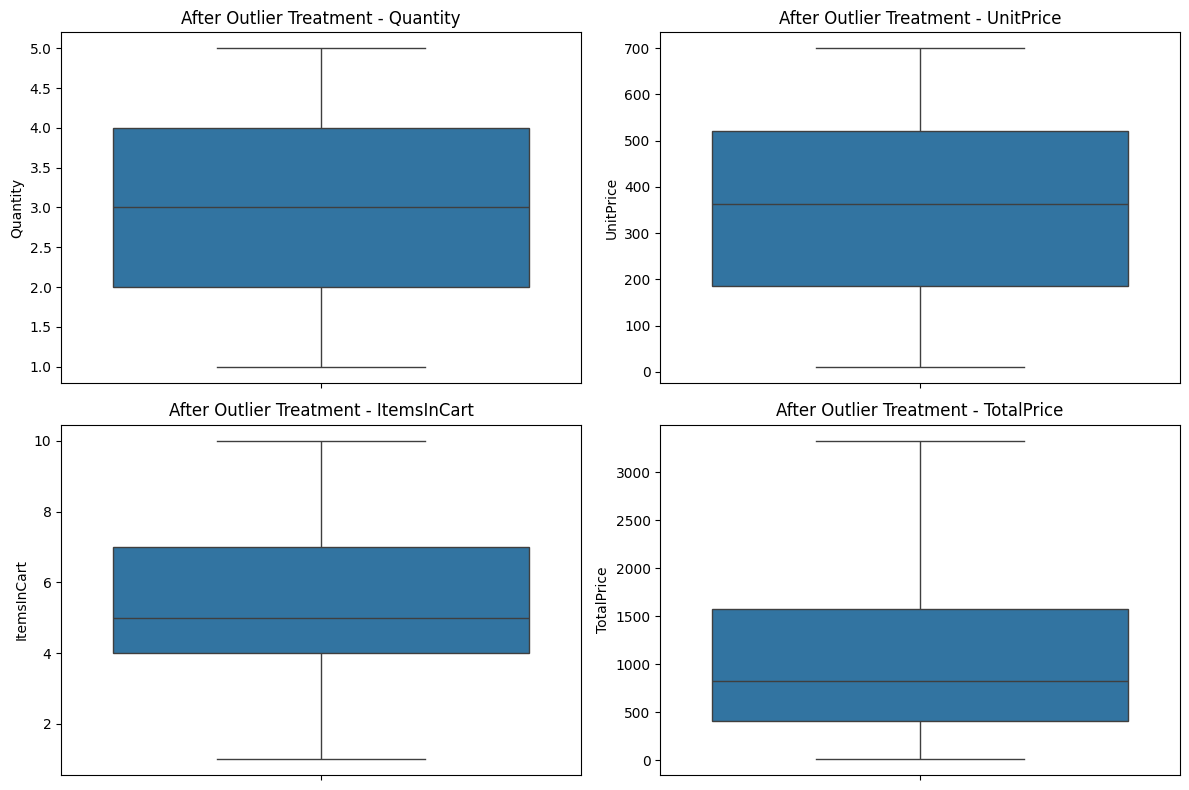

In [ ]:
plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(data[col])
    plt.title(f'After Outlier Treatment - {col}')

plt.tight_layout()
plt.show()

# Feature Engineering

In [25]:
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month

In [18]:
data['CouponUsed'] = np.where(data['CouponCode'] == 'N/A', 0, 1)

In [31]:
data['ItemsAbandoned'] = data['ItemsInCart'] - data['Quantity']

In [29]:
data['CartConversionRate'] = data['Quantity'] / data['ItemsInCart']

In [32]:
data['RevenuePerCartItem'] = data['TotalPrice'] / data['ItemsInCart']

# Updated Data

In [33]:
data.head(20)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,Month,CartConversionRate,ItemsAbandoned,RevenuePerCartItem
0,ORD200000,2023-01-04,C72649,Monitor,5.0,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7.0,SAVE10,Instagram,2853.10,1,1,0.714286,2.0,407.585714
1,ORD200001,2024-08-23,C75739,Phone,2.0,151.35,823 Main St,Online,Shipped,TRK91186779,3.0,SAVE10,Referral,302.70,1,8,0.666667,1.0,100.900000
2,ORD200002,2024-02-27,C81728,Tablet,5.0,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8.0,FREESHIP,Email,2753.40,1,2,0.625000,3.0,344.175000
3,ORD200003,2023-10-15,C33540,Chair,1.0,273.19,275 Main St,Debit Card,Returned,TRK62788070,5.0,SAVE10,Facebook,273.19,1,10,0.200000,4.0,54.638000
4,ORD200004,2025-05-08,C81840,Printer,4.0,626.01,668 Main St,Online,Delivered,TRK29241424,8.0,SAVE10,Email,2504.04,1,5,0.500000,4.0,313.005000
5,ORD200005,2023-10-23,C37249,Phone,2.0,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4.0,SAVE10,Instagram,491.72,1,10,0.500000,2.0,122.930000
6,ORD200006,2025-06-17,C83492,Laptop,1.0,664.42,986 Main St,Gift Card,Returned,TRK96417362,6.0,SAVE10,Facebook,664.42,1,6,0.166667,5.0,110.736667
7,ORD200007,2023-05-12,C41460,Monitor,5.0,149.55,706 Main St,Cash,Shipped,TRK78809193,9.0,FREESHIP,Facebook,747.75,1,5,0.555556,4.0,83.083333
8,ORD200008,2025-04-02,C26817,Phone,2.0,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2.0,N/A,Email,268.56,0,4,1.000000,0.0,134.280000
9,ORD200009,2023-11-21,C31946,Desk,4.0,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6.0,SAVE10,Google,2037.52,1,11,0.666667,2.0,339.586667
